# Analiza podatkov, povezanih s tržno vrednostjo 500 najvrednelših nogometnih igralcev

In [270]:
import pandas as pd
pd.set_option("display.max_rows", 16)
pd.set_option("display.min_rows", 16)
%matplotlib inline
IGRALCI = pd.read_csv("podatki/transfermarket/najvrednejsi_igralci.csv")
STATISTIKA = pd.read_csv("podatki/fbref/fbref_igralci.csv")
TEKMOVANJA = pd.read_csv("podatki/opta/moc_tekmovanj.csv")

In [127]:
IGRALCI

,uvrstitev,ime,starost,drzavljanstvo,klub,vrednost
0,1,Erling Haaland,26,Norway,Manchester City,220.0
1,2,Lamine Yamal,19,Spain,FC Barcelona,220.0
2,3,Kylian Mbappé,27,France,Real Madrid,200.0
3,4,Michael Olise,24,France,Bayern Munich,170.0
4,5,Jude Bellingham,23,England,Real Madrid,160.0
5,6,Pedri,23,Spain,FC Barcelona,150.0
6,7,Vinicius Junior,26,Brazil,Real Madrid,140.0
7,8,Vitinha,26,Portugal,Paris Saint-Germain,140.0
...,...,...,...,...,...,...
492,493,Vasilije Kostov,18,Serbia,Red Star Belgrade,25.0


In [128]:
STATISTIKA

,fbref_id,ime,tekmovanja,tekme,min,goli,asistence,G+A
0,29dd3b2e,Jones El-Abdellaoui,"['la_liga', 'europa_league', 'copa_del_rey']",31,1181,3,0,3
1,88824111,Tay Abed,['la_liga'],7,93,0,0,0
2,2bc7f211,Abdel Abqar,"['la_liga', 'copa_del_rey']",24,1457,0,2,2
3,2ccd39ed,Akor Adams,"['la_liga', 'copa_del_rey']",33,2154,10,4,14
4,f76e6b4e,Adrián,"['la_liga', 'copa_del_rey']",6,540,0,0,0
5,4b00cd47,David Affengruber,"['la_liga', 'copa_del_rey']",39,3093,1,2,3
6,a2c1a8d3,Julen Agirrezabala,"['la_liga', 'copa_del_rey']",19,1710,0,0,0
7,8bc8829a,Lucien Agoume,"['la_liga', 'copa_del_rey']",36,2799,1,4,5
...,...,...,...,...,...,...,...,...
19581,61a5541d,Zach Zandi,['us_open_cup'],1,45,0,0,0


In [129]:
TEKMOVANJA

,tekmovanje,moc
0,English Premier League,92.60
1,German Bundesliga,86.70
2,Spanish La Liga,86.70
3,Italian Serie A,86.60
4,French Ligue 1,85.80
5,Brazilian Serie A,83.20
6,Belgian Jupiler Pro League,82.10
7,Portuguese Primeira Liga,81.50
...,...,...
321,copa_libertadores,78.86


In [130]:
zdruzeni_podatki = pd.merge(IGRALCI, STATISTIKA, on="ime", how="left")
zdruzeni_podatki

,uvrstitev,ime,starost,drzavljanstvo,klub,vrednost,fbref_id,tekmovanja,tekme,min,goli,asistence,G+A
0,1,Erling Haaland,26,Norway,Manchester City,220.0,1f44ac21,"['premier_league', 'champions_league', 'fa_cup...",52.0,4135.0,38.0,9.0,47.0
1,2,Lamine Yamal,19,Spain,FC Barcelona,220.0,82ec26c1,"['la_liga', 'champions_league', 'copa_del_rey'...",45.0,3691.0,24.0,17.0,41.0
2,3,Kylian Mbappé,27,France,Real Madrid,200.0,42fd9c7f,"['la_liga', 'champions_league', 'copa_del_rey'...",44.0,3616.0,42.0,6.0,48.0
3,4,Michael Olise,24,France,Bayern Munich,170.0,c4486bac,"['bundesliga', 'champions_league', 'dfb_pokal']",51.0,3916.0,22.0,26.0,48.0
4,5,Jude Bellingham,23,England,Real Madrid,160.0,57d88cf9,"['la_liga', 'champions_league', 'copa_del_rey'...",40.0,2720.0,8.0,5.0,13.0
5,6,Pedri,23,Spain,FC Barcelona,150.0,0d9b2d31,"['la_liga', 'champions_league', 'copa_del_rey'...",43.0,3085.0,2.0,12.0,14.0
6,7,Vinicius Junior,26,Brazil,Real Madrid,140.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,Vitinha,26,Portugal,Paris Saint-Germain,140.0,74d4cec6,"['serie_a', 'coppa_italia']",36.0,2247.0,5.0,1.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
518,493,Vasilije Kostov,18,Serbia,Red Star Belgrade,25.0,c02be712,"['serbian_superliga', 'europa_league']",42.0,2972.0,14.0,7.0,21.0


In [131]:
#vrstic je 526 namesto 500 zato je prišlo pri združevanju do duplikatov
zdruzeni_podatki[zdruzeni_podatki.duplicated(subset=["ime"], keep=False)]

,uvrstitev,ime,starost,drzavljanstvo,klub,vrednost,fbref_id,tekmovanja,tekme,min,goli,asistence,G+A
7,8,Vitinha,26,Portugal,Paris Saint-Germain,140.0,74d4cec6,"['serie_a', 'coppa_italia']",36.0,2247.0,5.0,1.0,6.0
8,8,Vitinha,26,Portugal,Paris Saint-Germain,140.0,3b029691,"['ligue_1', 'champions_league', 'coupe_de_fran...",47.0,3752.0,7.0,8.0,15.0
41,41,João Pedro,24,Brazil,Chelsea FC,80.0,e8832875,"['premier_league', 'champions_league', 'fa_cup...",50.0,3676.0,20.0,6.0,26.0
42,41,João Pedro,24,Brazil,Chelsea FC,80.0,cd51f56f,"['serie_a_bra', 'copa_sudamericana']",17.0,1332.0,0.0,1.0,1.0
43,41,João Pedro,24,Brazil,Chelsea FC,80.0,31d1ed52,"['serie_a_bra', 'copa_sudamericana']",11.0,757.0,1.0,0.0,1.0
44,41,João Pedro,24,Brazil,Chelsea FC,80.0,81255c03,"['liga_mx', 'leagues_cup']",36.0,3209.0,28.0,1.0,29.0
55,52,Gabriel,28,Brazil,Arsenal FC,75.0,4fd28619,"['serie_a_bra', 'copa_sudamericana']",14.0,1038.0,0.0,0.0,0.0
56,52,Gabriel,28,Brazil,Arsenal FC,75.0,8dc3be2b,['serie_a_bra'],25.0,1592.0,5.0,2.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,472,André,25,Brazil,Wolverhampton Wanderers,25.0,867660e8,['serie_a_bra'],9.0,315.0,2.0,0.0,2.0


In [ ]:
zdruzeni_podatki[zdruzeni_podatki.isna().any(axis=1)]

,uvrstitev,ime,starost,drzavljanstvo,klub,vrednost,fbref_id,tekmovanja,tekme,min,goli,asistence,G+A
6,7,Vinicius Junior,26,Brazil,Real Madrid,140.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,12,Julián Alvarez,26,Argentina,Atlético de Madrid,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,23,Fermín López,23,Spain,FC Barcelona,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,32,Yan Diomande,19,Cote d'Ivoire,RB Leipzig,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,43,Hugo Ekitiké,24,France,Liverpool FC,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,45,Nico Paz,21,Argentina,Como 1907,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,46,Estêvão,19,Brazil,Chelsea FC,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,53,Jérémy Doku,24,Belgium,Manchester City,75.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,474,Javi Guerra,23,Spain,Valencia CF,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#imena nekaterih igralcev se v tabelah razlikujejo le za naglase, zato jih odstranimo s pomožno funkcijo
import unicodedata

def pocisti_ime(ime):
    niz = ''.join(c for c in unicodedata.normalize('NFKD', str(ime)) if not unicodedata.combining(c))
    return niz.replace("'", "").lower().strip()

IGRALCI["ime"] = IGRALCI["ime"].apply(pocisti_ime)

import unicodedata

def pocisti_ime(ime):
    niz = ''.join(c for c in unicodedata.normalize('NFKD', str(ime)) if not unicodedata.combining(c))
    return niz.replace("'", "").lower().strip()

STATISTIKA["ime"] = STATISTIKA["ime"].apply(pocisti_ime)


#Nekateri igralci imajo na transfermarket in fbref drugače zapisano ime, zato jih bom s slovarjem poenotil, da ne bom imel NaN
popravki = {
    "nico paz": "nicolas paz",
    "estevao": "estevao willian",
    "junior kroupi": "eli junior kroupi",
    "yann bisseck":	"yann aurel bisseck",
    "ederson": "ederson silva",
    "pio esposito": "francesco esposito",
    "samu aghehowa": "samu omorodion",
    "nico gonzalez": "nicolas gonzalez",
    "ilya zabarnyi": "illia zabarnyi",
    "ferdi kadıoglu": "ferdi kadioglu",
    "evan ndicka": "obite ndicka",
    "bremer": "gleison bremer",
    "savinho": "savio",
    "konstantinos karetsas": "kos karetsas",
    "yegor yarmolyuk": "yehor yarmoliuk",
    "matvey safonov": "matvei safonov",
    "fabian ruiz": "fabian ruiz pena",
    "gabri veiga": "gabriel veiga",
    "taty castellanos": "valentin castellanos",
    "kang-in lee": "lee kang-in",
    "aleksey batrakov": "aleksei batrakov",
    "karim coulibaly": "abdoul coulibaly",
    "anatoliy trubin": "anatolii trubin",
    "emmanuel emegha": "emanuel emegha",
    "georgiy sudakov": "heorhiy sudakov",
    "matvey kislyak": "matvei kisliak",
    "hakon arnar haraldsson": "hakon haraldsson",
    "javi guerra": "javier guerra",
    "jose manuel lopez": "flaco lopez",
    "jean-matteo bahoya": "jean matteo bahoya",
    "josh acheampong": "joshua acheampong",
    "josh king": "joshua king",
    "gabriel": "gabriel magalhaes"
}
IGRALCI["ime"] = IGRALCI["ime"].replace(popravki)
zdruzeni_podatki = pd.merge(IGRALCI, STATISTIKA, on="ime", how="left").drop(columns=["fbref_id"])

# Pri podvojenih igralcih sem opazil vzorec, da je vedno igralcev, ki sem ga potreboval (torej je med 500 najvrednejšimi igralci) odigral največ tekem z izjemo enega
zdruzeni_podatki = zdruzeni_podatki[(zdruzeni_podatki["ime"] != "romulo") | (zdruzeni_podatki["tekme"] == 32)]
zdruzeni_podatki = zdruzeni_podatki.sort_values(by="tekme", ascending=False)
zdruzeni_podatki["minute_na_tekmo"] = (zdruzeni_podatki["min"] / zdruzeni_podatki["tekme"]).round(2)


zdruzeni_podatki = zdruzeni_podatki.drop_duplicates(subset=["uvrstitev"], keep="first")
zdruzeni_podatki = zdruzeni_podatki.set_index("uvrstitev").sort_values(by="uvrstitev")
zdruzeni_podatki

,ime,starost,drzavljanstvo,klub,vrednost,tekmovanja,tekme,min,goli,asistence,G+A,minute_na_tekmo
uvrstitev,,,,,,,,,,,,
1,erling haaland,26,Norway,Manchester City,220.0,"['premier_league', 'champions_league', 'fa_cup...",52,4135,38,9,47,79.52
2,lamine yamal,19,Spain,FC Barcelona,220.0,"['la_liga', 'champions_league', 'copa_del_rey'...",45,3691,24,17,41,82.02
3,kylian mbappe,27,France,Real Madrid,200.0,"['la_liga', 'champions_league', 'copa_del_rey'...",44,3616,42,6,48,82.18
4,michael olise,24,France,Bayern Munich,170.0,"['bundesliga', 'champions_league', 'dfb_pokal']",51,3916,22,26,48,76.78
5,jude bellingham,23,England,Real Madrid,160.0,"['la_liga', 'champions_league', 'copa_del_rey'...",40,2720,8,5,13,68.00
6,pedri,23,Spain,FC Barcelona,150.0,"['la_liga', 'champions_league', 'copa_del_rey'...",43,3085,2,12,14,71.74
7,vinicius junior,26,Brazil,Real Madrid,140.0,"['la_liga', 'champions_league', 'copa_del_rey'...",53,4235,22,10,32,79.91
8,vitinha,26,Portugal,Paris Saint-Germain,140.0,"['ligue_1', 'champions_league', 'coupe_de_fran...",47,3752,7,8,15,79.83
...,...,...,...,...,...,...,...,...,...,...,...,...


## Osnovne značilnosti 500 najvrednejših nogometnih igralcev

In [177]:
opis = zdruzeni_podatki[["starost", "vrednost", "tekme", "min", "minute_na_tekmo", "goli", "asistence", "G+A"]].describe().round(2).drop(index="count")
opis = opis.rename(index={
    "mean": "povprecje",
    "std": "standardni odklon",
    "25%": "1. kvartil",
    "50%": "mediana",
    "75%": "3. kvartil"
    
}).rename(columns={
    "min": "minute"
})
opis



,starost,vrednost,tekme,minute,minute_na_tekmo,goli,asistence,G+A
povprecje,24.19,44.06,38.39,2702.78,69.73,6.25,4.08,10.33
standardni odklon,2.95,26.63,9.43,917.66,14.30,6.86,3.80,9.21
min,16.00,23.00,1.00,80.00,21.19,0.00,0.00,0.00
1. kvartil,22.00,28.00,33.00,2009.50,59.72,2.00,1.00,4.00
mediana,24.00,35.00,39.00,2750.50,72.00,4.00,3.00,8.00
3. kvartil,26.00,50.00,45.00,3341.75,81.54,9.00,6.00,14.25
max,33.00,220.00,67.00,4643.00,91.74,60.00,26.00,67.00


Povprečna starost igralcev znaša 24,19 leta, mediana pa 24 let, kar kaže, da je večina 500 najvrednejših igralcev v zgodnjih in srednjih dvajsetih letih. Povprečna tržna vrednost znaša 44,06 milijona, mediana pa 35 milijonov. Višje povprečje od mediane in maksimum 220 milijonov kažeta na desno asimetrično porazdelitev, saj manjše število zelo dragih igralcev zvišuje povprečje. Tri četrtine igralcev so vredne največ 50 milijonov.

Igralci so v povprečju odigrali 38,39 tekme oziroma približno 2703 minute, kar pomeni okoli 70 minut na tekmo. Večina igralcev iz vzorca ima torej veliko igralnega časa, kar je pričakovano, saj analiziramo samo 500 najvrednejših igralcev.

Povprečno število golov in asistenc skupaj znaša 10,33, mediana pa 8. Razpršenost je velika, saj nekateri igralci niso prispevali nobenega gola ali asistence, maksimum pa znaša 67. Pri interpretaciji teh podatkov je treba upoštevati, da vzorec vključuje igralce različnih igralnih položajev, zato goli in asistence ne predstavljajo enako primerne mere uspešnosti za vse igralce.

## Zastopanost igralcev po državljanstvu

drzavljanstvo
England             66
France              49
Spain               44
Brazil              39
Netherlands         30
Germany             29
Portugal            24
Italy               21
                    ..
Guinea               1
Montenegro           1
Korea, South         1
Armenia              1
Northern Ireland     1
Iceland              1
Mozambique           1
Mexico               1
Name: count, Length: 59, dtype: int64

drzavljanstvo
England             13.2
France               9.8
Spain                8.8
Brazil               7.8
Netherlands          6.0
Germany              5.8
Portugal             4.8
Italy                4.2
                    ... 
Guinea               0.2
Montenegro           0.2
Korea, South         0.2
Armenia              0.2
Northern Ireland     0.2
Iceland              0.2
Mozambique           0.2
Mexico               0.2
Name: proportion, Length: 59, dtype: float64

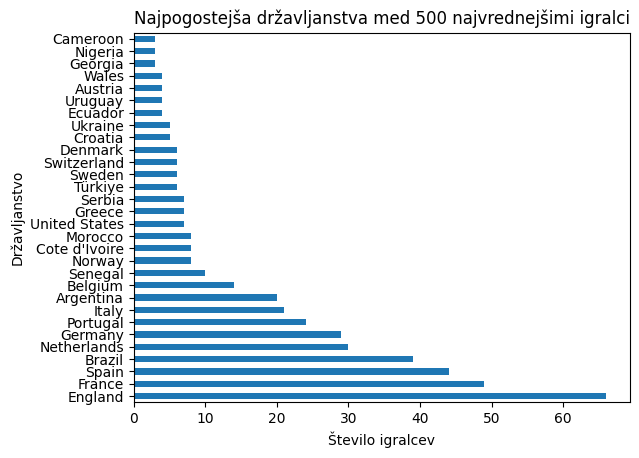

In [156]:
drzavljanstva = (zdruzeni_podatki["drzavljanstvo"].value_counts())
display(drzavljanstva)

top_drzavljanstva = (zdruzeni_podatki["drzavljanstvo"].value_counts().head(30))

top_drzavljanstva.plot(
    kind="barh", 
    title="Najpogostejša državljanstva med 500 najvrednejšimi igralci",
    xlabel="Število igralcev",
    ylabel="Državljanstvo"
)

delezi_drzavljanstev = (zdruzeni_podatki["drzavljanstvo"].value_counts(normalize=True)*100)
display(delezi_drzavljanstev)

Največ igralcev v vzorcu prihaja iz Anglije, in sicer 66 oziroma 13,2 %. Sledijo Francija z 49 igralci (9,8 %), Španija s 44 (8,8 %) in Brazilija z 39 (7,8 %). V vzorcu je zastopanih 59 različnih državljanstev, kar kaže na široko geografsko razpršenost igralcev.

Hkrati je prisotna določena koncentracija, saj prvih pet najpogostejših državljanstev predstavlja 45,6 % vseh igralcev. Najvrednejši igralci torej prihajajo iz velikega števila držav, vendar je skoraj polovica vzorca skoncentrirana v nekaj najbolj zastopanih državljanstvih.

## Zastopanost igralcev po klubih

klub
Chelsea FC              23
Manchester City         22
Arsenal FC              22
Manchester United       18
FC Barcelona            17
Real Madrid             17
Paris Saint-Germain     17
Tottenham Hotspur       17
                        ..
Valencia CF              1
US Sassuolo              1
Feyenoord Rotterdam      1
Red Star Belgrade        1
Club Tijuana             1
FC Nantes                1
Zenit St. Petersburg     1
Udinese Calcio           1
Name: count, Length: 88, dtype: int64

klub
Chelsea FC              4.6
Manchester City         4.4
Arsenal FC              4.4
Manchester United       3.6
FC Barcelona            3.4
Real Madrid             3.4
Paris Saint-Germain     3.4
Tottenham Hotspur       3.4
                       ... 
Valencia CF             0.2
US Sassuolo             0.2
Feyenoord Rotterdam     0.2
Red Star Belgrade       0.2
Club Tijuana            0.2
FC Nantes               0.2
Zenit St. Petersburg    0.2
Udinese Calcio          0.2
Name: proportion, Length: 88, dtype: float64

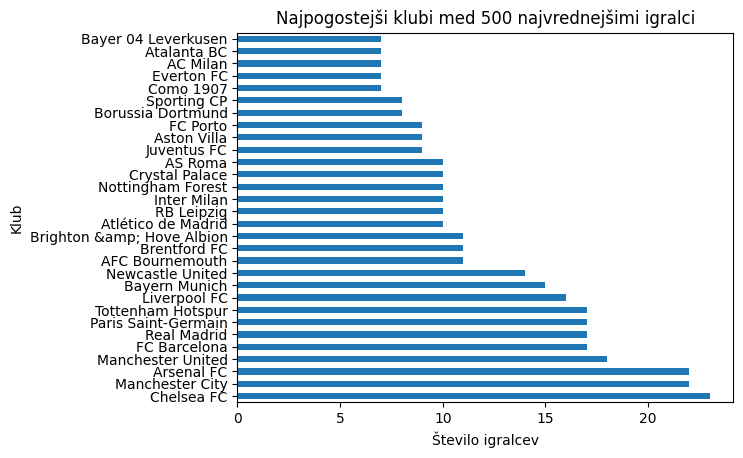

In [158]:
klubi = (zdruzeni_podatki["klub"].value_counts())
display(klubi)

top_klubi = (zdruzeni_podatki["klub"].value_counts().head(30))

top_klubi.plot(
    kind="barh", 
    title="Najpogostejši klubi med 500 najvrednejšimi igralci",
    xlabel="Število igralcev",
    ylabel="Klub"
)

delezi_klubov = (zdruzeni_podatki["klub"].value_counts(normalize=True)*100)
display(delezi_klubov)

Največ igralcev med 500 najvrednejšimi ima Chelsea, in sicer 23 oziroma 4,6 %. Manchester City in Arsenal imata po 22 igralcev (4,4 %), Manchester United 18 (3,6 %), Barcelona, Real Madrid, Paris Saint-Germain in Tottenham pa po 17 (3,4 %).

V primerjavi z državljanstvi je porazdelitev po klubih manj koncentrirana, saj noben posamezen klub ne predstavlja niti 5 % vseh igralcev. Najvrednejši igralci so tako razporejeni med večje število.

## Zastopanost igralcev po ligah

In [181]:
import ast

zdruzeni_podatki["tekmovanja"] = zdruzeni_podatki["tekmovanja"].apply(ast.literal_eval)
zdruzeni_podatki["liga"] = zdruzeni_podatki["tekmovanja"].str[0]

zdruzeni_podatki[["ime", "liga"]].head()

lige = zdruzeni_podatki["liga"].value_counts()
lige

top_lige = zdruzeni_podatki["liga"].value_counts().head(15)
top_lige

tabela_lig = pd.DataFrame({
    "stevilo_igralcev": top_lige, 
    "delez_v_%": top_lige / len(zdruzeni_podatki) * 100
})
tabela_lig

top_5_igralci = top_lige.head(5).sum()
top_5_delez = top_5_igralci / len(zdruzeni_podatki) * 100

display(tabela_lig)

f"Najmočnejših 5 lig skupaj: {top_5_igralci} igralcev ({top_5_delez} %)"

,stevilo_igralcev,delez_v_%
liga,,
premier_league,208,41.6
serie_a,62,12.4
bundesliga,59,11.8
la_liga,58,11.6
ligue_1,46,9.2
primeira_liga,28,5.6
eredivisie,7,1.4
belgian_pro_league,6,1.2
super_lig,5,1.0


'Najmočnejših 5 lig skupaj: 433 igralcev (86.6 %)'

Premier League močno izstopa, saj v njej nastopa 208 oziroma 41,6 % vseh igralcev iz vzorca. Sledijo Serie A z 12,4 %, Bundesliga z 11,8 %, La Liga z 11,6 % in Ligue 1 z 9,2 %. Pet najbolj zastopanih lig skupaj vključuje 433 igralcev oziroma 86,6 % celotnega vzorca.

Rezultat kaže na zelo veliko koncentracijo 500 najvrednejših igralcev v petih najbolj zastopanih evropskih ligah, pri čemer posebej izstopa Premier League.

## Povezava med starostjo in tržno vrednostjo

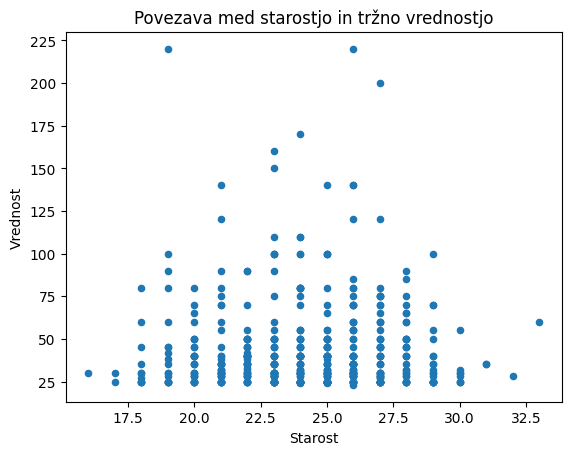

,število,povprečje,mediana
starost,,,
16,1,30.00,30.0
17,2,27.50,27.5
18,11,37.00,30.0
19,18,53.78,36.5
20,29,39.45,35.0
21,38,43.71,32.0
22,42,40.17,39.0
23,60,44.18,32.5
24,60,47.35,40.0


np.int64(12)

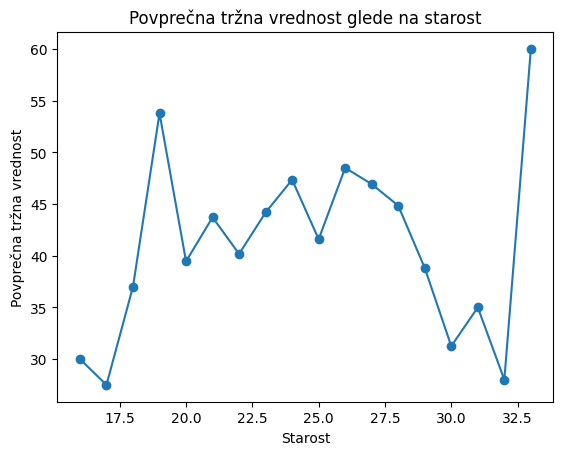

In [202]:
import matplotlib.pyplot as plt

zdruzeni_podatki.plot(
    kind="scatter",
    x="starost",
    y="vrednost",
    title="Povezava med starostjo in tržno vrednostjo",
    xlabel="Starost",
    ylabel="Vrednost"
)

plt.show()

vrednost_po_starosti = (
    zdruzeni_podatki
    .groupby("starost")["vrednost"]
    .agg(["count", "mean", "median"])
     .round(2)
     .rename(columns={"count": "število", "mean": "povprečje", "median": "mediana"})
     )

pd.set_option("display.max_row", 20)
display(vrednost_po_starosti)

filter_starejši_30 = zdruzeni_podatki["starost"] >= 30
display(filter_starejši_30.sum())

vrednost_po_starosti["povprečje"].plot(
    kind="line",
    marker="o",
    title="Povprečna tržna vrednost glede na starost",
    xlabel="Starost",
    ylabel="Povprečna tržna vrednost"
)

plt.show()

Največ igralcev je starih med zgodnjimi in poznimi dvajsetimi leti, medtem ko je zelo mladih in starejših igralcev precej manj. V vzorcu je samo 12 igralcev, starih 30 let ali več, zato so starejši igralci med 500 najvrednejšimi redki.

Iz scatter grafa in povprečnih vrednosti po starosti ni razvidna enostavna linearna povezava, po kateri bi vrednost s starostjo ves čas naraščala ali padala. Najvišje tržne vrednosti se pojavljajo predvsem med igralci v zgodnjih in srednjih dvajsetih letih.

Povprečne vrednosti pri najmlajših in najstarejših starostih je treba interpretirati previdno, saj posamezne starosti predstavljajo le eden ali dva igralca. Na primer pri 33 letih je v vzorcu samo en igralec, zato njegova vrednost sama določa povprečje za celotno starostno skupino.

## Povezava med igralnim časom in tržno vrednostjo

In [205]:
zdruzeni_podatki[["tekme", "min", "minute_na_tekmo"]].describe()
zdruzeni_podatki[
    ["tekme", "min", "minute_na_tekmo", "vrednost"]
].corr()["vrednost"].round(2)

tekme              0.31
min                0.29
minute_na_tekmo    0.11
vrednost           1.00
Name: vrednost, dtype: float64

Igralci v vzorcu imajo praviloma veliko igralnega časa. Povprečen igralec je nastopil na približno 38 tekmah in zbral okoli 2703 minute, povprečno pa je igral približno 70 minut na tekmo. Ker vzorec vključuje samo 500 najvrednejših igralcev, že v izhodišču večinoma analiziramo igralce z redno minutažo. Zaradi tega so razlike v igralnem času omejene, zato igralni čas sam po sebi verjetno ne bo dobro ločeval najdražjih igralcev od preostanka vzorca.

## Povezava med povprečno močjo tekmovanj in tržno vrednostjo

povprecje            85.93
standardni odklon     2.47
min                  71.80
1. kvartil           85.12
mediana              86.43
3. kvartil           87.38
max                  93.04
Name: povprecna_moc_tekmovanj, dtype: float64

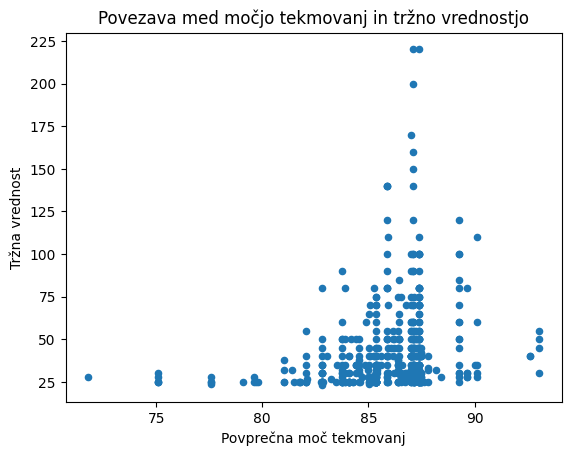

In [247]:
moc_tekmovanj = TEKMOVANJA.set_index("tekmovanje")["moc"].to_dict()

imena_tekmovanj = {
    "belgian_pro_league": "Belgian Jupiler Pro League",
    "bundesliga": "German Bundesliga",
    "championship": "English Championship",
    "coppa_italia": "coppa_italiana",
    "eredivisie": "Dutch Eredivisie",
    "la_liga": "Spanish La Liga",
    "liga_mx": "Mexican Primera",
    "ligue_1": "French Ligue 1",
    "premier_league": "English Premier League",
    "primeira_liga": "Portuguese Primeira Liga",
    "russian_premier_league": "Russian Premier League",
    "saudi_pro_league": "Saudi Arabian League",
    "segunda_division": "Spanish Segunda Division",
    "serbian_superliga": "Serbian Super Liga",
    "serie_a": "Italian Serie A",
    "serie_a_bra": "Brazilian Serie A",
    "super_league_greece": "Greek Super League",
    "super_lig": "Turkish Super Lig"
}

for fbref_ime, opta_ime in imena_tekmovanj.items():
    moc_tekmovanj[fbref_ime] = moc_tekmovanj[opta_ime]

def izracunaj_povprecno_moc(tekmovanja):
    moci = [moc_tekmovanj[tekmovanje] for tekmovanje in tekmovanja]
    return sum(moci) / len(moci)


zdruzeni_podatki["povprecna_moc_tekmovanj"] = (
    zdruzeni_podatki["tekmovanja"]
    .apply(izracunaj_povprecno_moc)
    .round(2)
)

display(
    zdruzeni_podatki["povprecna_moc_tekmovanj"]
    .describe().round(2).drop(index="count")
    .rename(index={
    "mean": "povprecje",
    "std": "standardni odklon",
    "25%": "1. kvartil",
    "50%": "mediana",
    "75%": "3. kvartil"}))

zdruzeni_podatki.plot(
    kind="scatter",
    x="povprecna_moc_tekmovanj",
    y="vrednost",
    title="Povezava med močjo tekmovanj in tržno vrednostjo",
    xlabel="Povprečna moč tekmovanj",
    ylabel="Tržna vrednost"
)

plt.show()

Povprečna moč tekmovanj, v katerih igralci nastopajo, znaša 85,93, mediana pa 86,43. Standardni odklon znaša samo 2,47, polovica vseh igralcev pa se nahaja med vrednostma 85,12 in 87,38. To kaže, da večina 500 najvrednejših igralcev nastopa v podobno močnem tekmovalnem okolju.

Scatter graf nakazuje rahlo tendenco višjih tržnih vrednosti pri igralcih iz močnejših tekmovanj, vendar je razpršenost velika. Pri podobni povprečni moči tekmovanj imajo igralci zelo različne tržne vrednosti. Moč tekmovalnega okolja zato sama ne pojasni velikih razlik med vrednostmi igralcev.

Pri interpretaciji je treba upoštevati tudi omejen vzorec: analiziramo samo 500 najvrednejših igralcev, ki že večinoma nastopajo v relativno močnih tekmovanjih, zato je razpon tega dejavnika precej majhen.

## Povezava med napadalno uspešnostjo in tržno vrednostjo

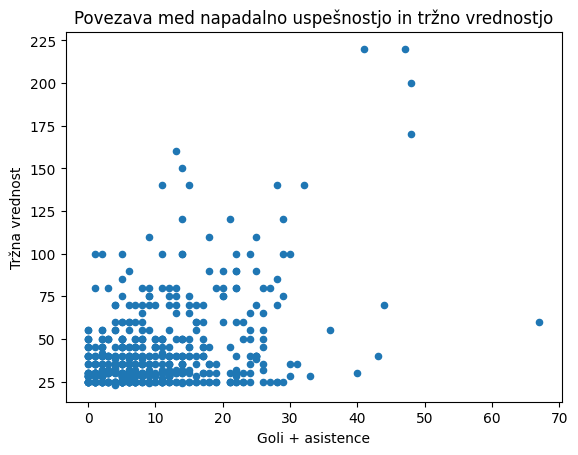

,stevilo_igralcev,povprecna_vrednost,mediana_vrednosti
GA_kvartil,,,
1. kvartil,142,35.90,30.0
2. kvartil,127,38.49,35.0
3. kvartil,106,46.16,35.0
4. kvartil,125,57.21,45.0


povprecje            0.35
standardni odklon    0.28
min                  0.00
1. kvartil           0.13
mediana              0.30
3. kvartil           0.53
max                  1.53
Name: GA_90, dtype: float64

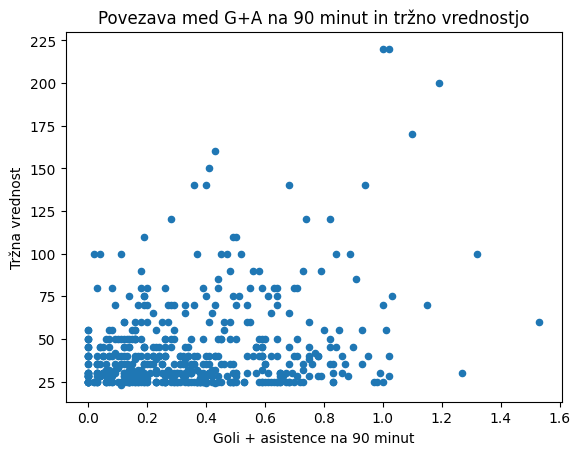

povprecje             885.73
standardni odklon     791.60
min                     0.00
1. kvartil            341.36
mediana               682.72
3. kvartil           1252.14
max                  5828.33
Name: koeficient_igralca, dtype: float64

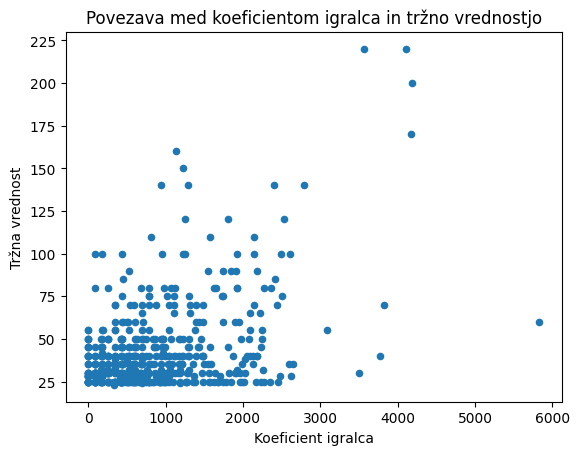

In [251]:
zdruzeni_podatki.plot(
    kind="scatter",
    x="G+A",
    y="vrednost",
    title="Povezava med napadalno uspešnostjo in tržno vrednostjo",
    xlabel="Goli + asistence",
    ylabel="Tržna vrednost"
)

plt.show()

zdruzeni_podatki["GA_kvartil"] = pd.qcut(
    zdruzeni_podatki["G+A"],
    q=4,
    labels=["1. kvartil", "2. kvartil", "3. kvartil", "4. kvartil"]
)

primerjava_GA = (
    zdruzeni_podatki
    .groupby("GA_kvartil", observed=True)
    .agg(
        stevilo_igralcev=("vrednost", "count"),
        povprecna_vrednost=("vrednost", "mean"),
        mediana_vrednosti=("vrednost", "median")
    )
    .round(2)
)

display(primerjava_GA)

# G+A na 90 minut
zdruzeni_podatki["GA_90"] = (
    zdruzeni_podatki["G+A"]
    / zdruzeni_podatki["min"]
    * 90
).round(2)

display(zdruzeni_podatki["GA_90"]
        .describe().round(2)
        .drop(index="count")
        .rename(index={
            "mean": "povprecje",
            "std": "standardni odklon",
            "25%": "1. kvartil",
            "50%": "mediana",
            "75%": "3. kvartil"})
            )

# 2. G+A na 90 minut in tržna vrednost
zdruzeni_podatki.plot(
    kind="scatter",
    x="GA_90",
    y="vrednost",
    title="Povezava med G+A na 90 minut in tržno vrednostjo",
    xlabel="Goli + asistence na 90 minut",
    ylabel="Tržna vrednost"
)

plt.show()

# Napadalna uspešnost prilagojena moči tekmovanj
zdruzeni_podatki["koeficient_igralca"] = (
    zdruzeni_podatki["G+A"] * zdruzeni_podatki["povprecna_moc_tekmovanj"]
)

display(zdruzeni_podatki["koeficient_igralca"]
        .describe().round(2)
        .drop(index="count")
        .rename(index={
            "mean": "povprecje",
            "std": "standardni odklon",
            "25%": "1. kvartil",
            "50%": "mediana",
            "75%": "3. kvartil"})
        )

# 3. Prilagojena napadalna uspešnost in tržna vrednost
zdruzeni_podatki.plot(
    kind="scatter",
    x="koeficient_igralca",
    y="vrednost",
    title="Povezava med koeficientom igralca in tržno vrednostjo",
    xlabel="Koeficient igralca",
    ylabel="Tržna vrednost"
)

plt.show()

Primerjava kvartilov kaže precej jasen vzorec. Igralci v četrtini z najmanj goli in asistencami imajo povprečno tržno vrednost 35,90 milijona, v drugem kvartilu 38,49 milijona, v tretjem 46,16 milijona, v četrtini z največ G+A pa 57,21 milijona. Tudi mediana se poveča s 30 milijonov v prvem kvartilu na 45 milijonov v četrtem. Višja skupna napadalna produkcija je torej v tem vzorcu povezana z višjo tržno vrednostjo.

Pri G+A na 90 minut znaša povprečje 0,35, mediana 0,30, tri četrtine igralcev pa dosegajo največ 0,53 G+A na 90 minut. Najvišja vrednost je 1,53. Scatter graf pokaže precejšnjo razpršenost, zato visoka učinkovitost na 90 minut sama po sebi še ne pomeni visoke tržne vrednosti.

Koeficient igralca združuje skupno število golov in asistenc s povprečno močjo tekmovanj. Njegova mediana znaša 682,72, povprečje 885,73, maksimum pa 5828,33, kar kaže na močno desno asimetrično porazdelitev. Scatter graf tudi tukaj kaže pozitivno tendenco, vendar ostaja precejšnja razpršenost vrednosti.

Pri vseh teh rezultatih je pomembna omejitev, da nimamo podatka o igralnem položaju. Goli in asistence so veliko bolj primerna mera napadalne produkcije za napadalce in ofenzivne veziste kot za branilce in vratarje, zato koeficienta ne smemo interpretirati kot splošno mero kakovosti igralca.

## Povezava med klubom in tržno vrednostjo

,stevilo_igralcev,povprecna_vrednost,povprečni_koeficient
klub,,,
Paris Saint-Germain,17,74.88,928.36
Real Madrid,17,74.41,1056.13
FC Barcelona,17,70.59,1137.86
Manchester City,22,64.00,919.08
Bayern Munich,15,63.00,1663.39
Arsenal FC,22,58.18,879.29
Liverpool FC,16,54.56,732.35
Chelsea FC,23,53.17,843.61
...,...,...,...


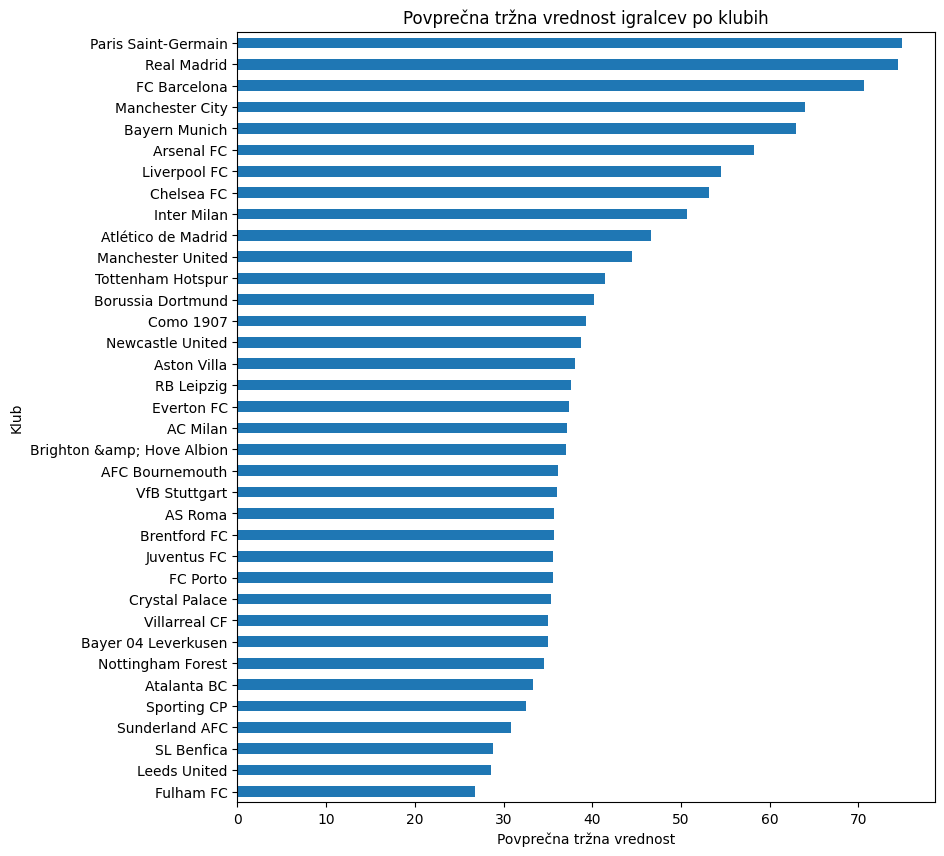

klub
Chelsea FC             23
Manchester City        22
Arsenal FC             22
Manchester United      18
FC Barcelona           17
Real Madrid            17
Paris Saint-Germain    17
Tottenham Hotspur      17
Liverpool FC           16
Bayern Munich          15
Name: count, dtype: int64

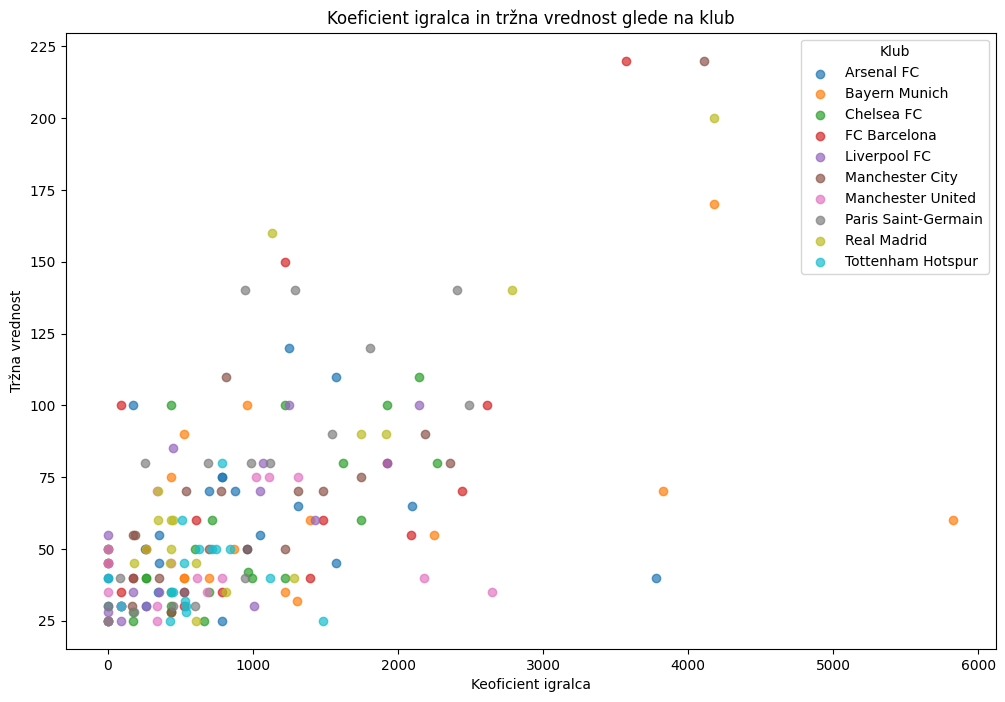

In [281]:
vrednost_po_klubih = (
    zdruzeni_podatki
    .groupby("klub")
    .agg(
        stevilo_igralcev=("vrednost", "count"),
        povprecna_vrednost=("vrednost", "mean"),
        povprečni_koeficient=("koeficient_igralca", "mean")
    )
    .round(2)
)

vrednost_po_klubih = (
    vrednost_po_klubih[
        vrednost_po_klubih["stevilo_igralcev"] >= 5
    ].sort_values("povprecna_vrednost",ascending=False)
)

display(vrednost_po_klubih)

vrednost_po_klubih["povprecna_vrednost"].sort_values().plot(
    kind="barh",
    figsize=(9, 10),
    title="Povprečna tržna vrednost igralcev po klubih",
    xlabel="Povprečna tržna vrednost",
    ylabel="Klub"
)

plt.show()

najpogostejsi_klubi = (
    zdruzeni_podatki["klub"]
    .value_counts()
    .head(10)
    .index
)

podatki_klubi = zdruzeni_podatki[
    zdruzeni_podatki["klub"].isin(najpogostejsi_klubi)
]

display(
    zdruzeni_podatki["klub"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,8))

for klub, podatki in podatki_klubi.groupby("klub"):
    plt.scatter(
        podatki["koeficient_igralca"],
        podatki["vrednost"],
        label = klub,
        alpha = 0.7
    )
plt.title("Koeficient igralca in tržna vrednost glede na klub")
plt.xlabel("Keoficient igralca")
plt.ylabel("Tržna vrednost")
plt.legend(title="Klub")
plt.show()

Med klubi so opazne precejšnje razlike v povprečnih tržnih vrednostih njihovih igralcev. Med klubi z najmanj petimi igralci v vzorcu imajo najvišjo povprečno vrednost Paris Saint-Germain, Real Madrid in Barcelona.

Vendar razlike v vrednosti niso neposredno sorazmerne z napadalnim koeficientom igralcev. Na primer Bayern ima višji povprečni koeficient igralca kot PSG, Real Madrid in Barcelona, kljub temu pa je njegova povprečna tržna vrednost nižja. To kaže, da napadalna produkcija in moč tekmovanj sami ne pojasnita vseh razlik med klubi.

Scatter graf desetih najbolj zastopanih klubov to še bolje pokaže. Na splošno se pri višjem koeficientu pojavljajo tudi višje tržne vrednosti, vendar imajo igralci s podobnim koeficientom pogosto zelo različne vrednosti in pripadajo različnim klubom. Pri koeficientih približno med 1000 in 1500 se na primer pojavljajo igralci z vrednostmi od približno 30 milijonov do več kot 150 milijonov.

Rezultati zato nakazujejo, da je klub lahko povezan s tržno vrednostjo igralca tudi pri približno podobni napadalni produkciji. Iz te analize pa ne moremo sklepati, da klub povzroča višjo vrednost, saj se igralci lahko razlikujejo po številnih drugih lastnostih, ki jih v analizi nismo upoštevali.

## Povezava med državljanstvom in tržno vrednostjo

,stevilo_igralcev,povprecna_vrednost,povprečni_koeficient
drzavljanstvo,,,
Norway,8,60.00,1203.63
Croatia,5,52.00,683.86
France,49,51.84,871.98
Türkiye,6,50.00,1325.12
Argentina,20,48.75,1125.83
Portugal,24,48.25,985.32
Spain,44,47.84,753.53
Morocco,8,47.50,1068.32
...,...,...,...


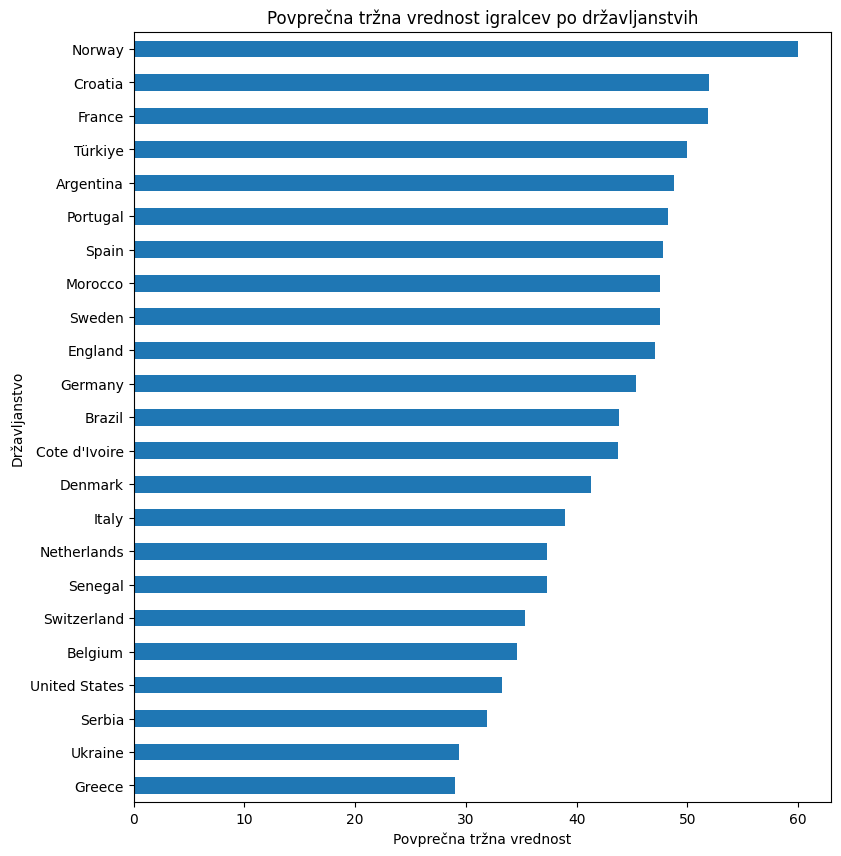

drzavljanstvo
England        66
France         49
Spain          44
Brazil         39
Netherlands    30
Germany        29
Portugal       24
Italy          21
Argentina      20
Belgium        14
Name: count, dtype: int64

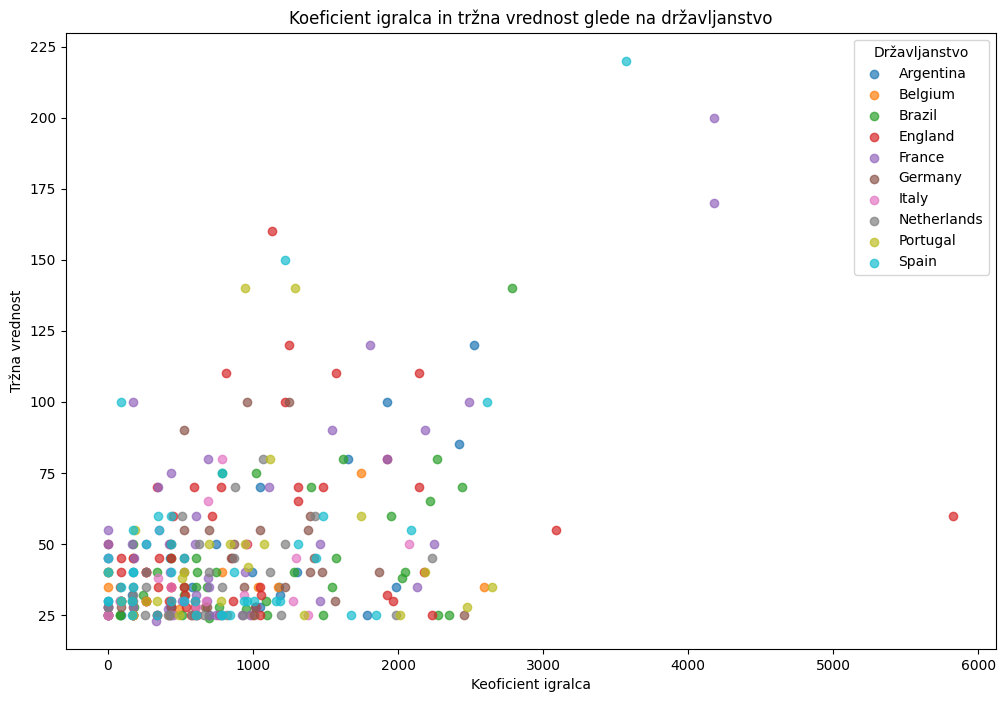

In [283]:
vrednost_po_drzavljanstvih = (
    zdruzeni_podatki
    .groupby("drzavljanstvo")
    .agg(
        stevilo_igralcev=("vrednost", "count"),
        povprecna_vrednost=("vrednost", "mean"),
        povprečni_koeficient=("koeficient_igralca", "mean")
    )
    .round(2)
)

vrednost_po_drzavljanstvih = (
    vrednost_po_drzavljanstvih[
        vrednost_po_drzavljanstvih["stevilo_igralcev"] >= 5
    ].sort_values("povprecna_vrednost",ascending=False)
)

display(vrednost_po_drzavljanstvih)

vrednost_po_drzavljanstvih["povprecna_vrednost"].sort_values().plot(
    kind="barh",
    figsize=(9, 10),
    title="Povprečna tržna vrednost igralcev po državljanstvih",
    xlabel="Povprečna tržna vrednost",
    ylabel="Državljanstvo"
)

plt.show()

najpogostejsa_drzavljanstva = (
    zdruzeni_podatki["drzavljanstvo"]
    .value_counts()
    .head(10)
    .index
)

podatki_drzavljanstva = zdruzeni_podatki[
    zdruzeni_podatki["drzavljanstvo"].isin(najpogostejsa_drzavljanstva)
]

display(
    zdruzeni_podatki["drzavljanstvo"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,8))

for drzavljanstvo, podatki in podatki_drzavljanstva.groupby("drzavljanstvo"):
    plt.scatter(
        podatki["koeficient_igralca"],
        podatki["vrednost"],
        label = drzavljanstvo,
        alpha = 0.7
    )
plt.title("Koeficient igralca in tržna vrednost glede na državljanstvo")
plt.xlabel("Keoficient igralca")
plt.ylabel("Tržna vrednost")
plt.legend(title="Državljanstvo")
plt.show()

Med državljanstvi obstajajo razlike v povprečni tržni vrednosti. Najvišjo povprečno vrednost ima Norveška, vendar je v vzorcu samo osem norveških igralcev, zato je rezultat precej bolj občutljiv na posamezne zelo drage igralce. Pri bolj zastopanih državljanstvih so rezultati stabilnejši: Francija ima 49 igralcev s povprečno vrednostjo 51,84 milijona, Španija pa 44 igralcev s povprečno vrednostjo 47,84 milijona.

Scatter graf desetih najbolj zastopanih državljanstev kaže veliko prekrivanje med državami. Igralci različnih državljanstev se pojavljajo pri zelo podobnih koeficientih in zelo različnih tržnih vrednostih, prav tako pa se velika razpršenost pojavlja znotraj posameznih državljanstev.

Za razliko od klubskega grafa pri državljanstvih ni opaziti izrazitega ločevanja posameznih skupin. Zato iz teh podatkov ni mogoče sklepati na jasno ali enostavno povezavo med državljanstvom in tržno vrednostjo. Razlike v povprečjih obstajajo, vendar so lahko povezane tudi s sestavo posamezne skupine in z majhnim številom igralcev pri nekaterih državljanstvih.

## Primerjava povezanosti numeričniih podatkov s tržno vrednsotjo

,dejavnik,korelacija_z_vrednostjo
0,Koeficient igralca,0.43
1,Goli + asistence,0.42
2,Število tekem,0.31
3,Igralne minute,0.29
4,G+A na 90 minut,0.28
5,Povprečna moč tekmovanj,0.23
6,Minute na tekmo,0.11
7,Starost,0.01


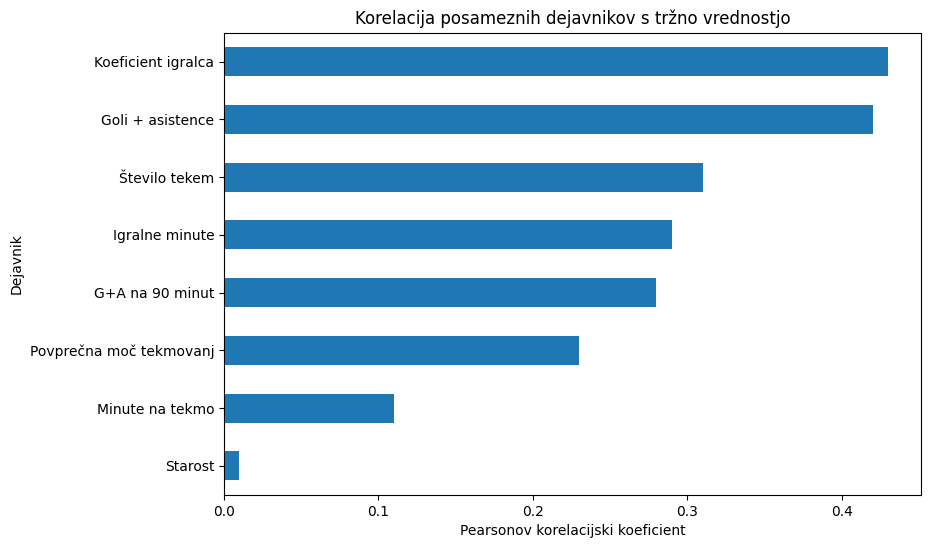

In [273]:
dejavniki = [
    "starost",
    "tekme",
    "min",
    "minute_na_tekmo",
    "povprecna_moc_tekmovanj",
    "G+A",
    "GA_90",
    "koeficient_igralca"
]

korelacije = []

for dejavnik in dejavniki:
    r = zdruzeni_podatki[dejavnik].corr(
        zdruzeni_podatki["vrednost"]
    )
   
    korelacije.append({
        "dejavnik": dejavnik,
        "korelacija_z_vrednostjo": r
    })

primerjava_korelacij = pd.DataFrame(korelacije)

primerjava_korelacij["absolutna_korelacija"] = (
    primerjava_korelacij["korelacija_z_vrednostjo"].abs()
)

primerjava_korelacij = (
    primerjava_korelacij
    .sort_values("absolutna_korelacija", ascending=False)
    .drop(columns="absolutna_korelacija")
    .reset_index(drop=True)
)

primerjava_korelacij["korelacija_z_vrednostjo"] = (
    primerjava_korelacij["korelacija_z_vrednostjo"].round(2)
)

imena_dejavnikov = {
    "starost": "Starost",
    "tekme": "Število tekem",
    "min": "Igralne minute",
    "minute_na_tekmo": "Minute na tekmo",
    "povprecna_moc_tekmovanj": "Povprečna moč tekmovanj",
    "G+A": "Goli + asistence",
    "GA_90": "G+A na 90 minut",
    "koeficient_igralca": "Koeficient igralca"
}

primerjava_korelacij["dejavnik"] = (
    primerjava_korelacij["dejavnik"]
    .replace(imena_dejavnikov)
)

display(primerjava_korelacij)

primerjava_korelacij_graf = (
    primerjava_korelacij
    .sort_values("korelacija_z_vrednostjo")
)

primerjava_korelacij_graf.plot(
    kind="barh",
    x="dejavnik",
    y="korelacija_z_vrednostjo",
    legend=False,
    figsize=(9, 6),
    title="Korelacija posameznih dejavnikov s tržno vrednostjo",
    xlabel="Pearsonov korelacijski koeficient",
    ylabel="Dejavnik"
)

plt.show()


Med analiziranimi numeričnimi dejavniki ima najvišjo Pearsonovo korelacijo s tržno vrednostjo koeficient igralca (r = 0,43), zelo podobna pa je korelacija skupnega števila golov in asistenc (r = 0,42). Obe povezavi sta zmerno pozitivni. Dodajanje povprečne moči tekmovanj v koeficient igralca torej povezanost izboljša le minimalno, za 0,01.

Število tekem (r = 0,31) in skupno število minut (r = 0,29) kažeta šibko do zmerno pozitivno povezavo. G+A na 90 minut ima korelacijo r = 0,28, povprečna moč tekmovanj r = 0,23, minute na tekmo pa samo r = 0,11.

Starost ima linearno korelacijo samo r = 0,01. Tega ne smemo interpretirati kot dokaz, da starost ni povezana s tržno vrednostjo. Analiza po starostih je pokazala, da je povezava verjetno nelinearna, saj so najvišje vrednosti skoncentrirane predvsem v določenem starostnem območju. Pearsonov koeficient takšne povezave ne zajame dobro.

Pomembno je tudi, da koeficient igralca ni neodvisen dejavnik, saj je sestavljen iz G+A in povprečne moči tekmovanj. Njegova nekoliko višja korelacija zato predvsem kaže, da upoštevanje tekmovalnega okolja nekoliko dopolni informacijo, ki jo že vsebuje G+A.

Nobena izmed analiziranih numeričnih spremenljivk nima korelacije višje od 0,5. Rezultati tako kažejo, da tržne vrednosti igralcev ni mogoče dobro pojasniti samo z enim izmed obravnavanih dejavnikov. Najmočnejša povezava v tem vzorcu je povezana z napadalno produkcijo, vendar tudi pri njej ostaja velika razpršenost.